<script src="/course_model/toc.js"></script>

# Visualize Data with Seaborn

This tutorial shows common charts made with the Seaborn and Matplotlib libraries.

**Outcomes**:
- Create a bar plot
- Create a count plot
- Create a histogram
- Create a box plot
- Create a scatter plot
- Create a pair plot
- Customize chart titles and axis labels
- Change chart styles and color palettes
- Use pre-built code to quickly visualize a dataset

**Links:**
- [template](template.ipynb)

**Optional Reading**
- [Handbook: Seaborn](https://jakevdp.github.io/PythonDataScienceHandbook/04.14-visualization-with-seaborn.html)


## Bar Plot

Use *bar* plots to compare means or medians across categories.

Required:

- `data = dataframe`: your dataset
- `x = 'fieldname of category'`: categorical variable
- `y = 'fieldname of quantitative'`: quantitative variable (or switch to x for a horizontal bar plot)

Optional:

- `hue = 'fieldname of category'`: adds color grouping for each bar
- `estimator = np.mean`: function to compute the value to be plotted (default is mean, but you can use np.median, np.sum, etc.)
- `errorbar = ('ci', 95)`: confidence interval for the estimate (default is 95%)


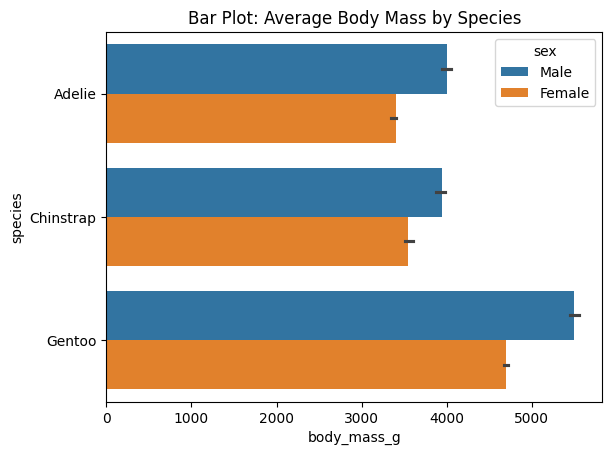

In [22]:
# Barplot Example
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df_penguins = sns.load_dataset("penguins")

# Bar plot: average body mass by species
sns.barplot(data=df_penguins, y="species", x="body_mass_g", hue="sex", errorbar = ('ci', 50), estimator=np.median)
plt.title("Bar Plot: Average Body Mass by Species")
plt.show()


### Count Plot

Similar to bar plot, but for counting occurrences of categories.

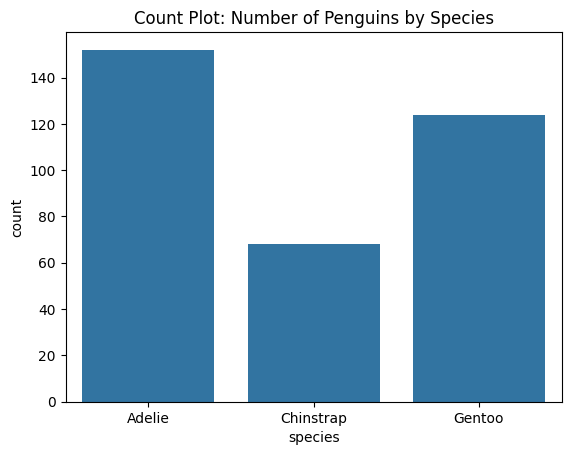

In [23]:
# Count plot: frequency of species

sns.countplot(data=df_penguins, x="species")
plt.title("Count Plot: Number of Penguins by Species")
plt.show()

## Line Plot

Show trends over time 

Required:
- `data = dataframe`: your dataset
- `x = 'fieldname of quantitative'`: quantitative variable for x-axis
- `y = 'fieldname of quantitative'`: quantitative variable for y-axis

Optional:
- `hue = 'fieldname of category'`: adds color grouping for each line. Disables error bars by default.
- `estimator = np.mean`: function to compute the value to be plotted (default is mean)
- `errorbar = ('ci', 95)`: None or a tuple with the confidence interval for the estimate (default is 95%)


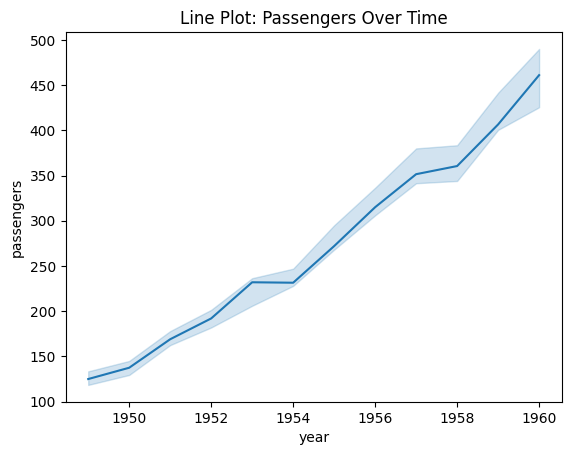

In [24]:
# Lineplot
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load example dataset
df_flights = sns.load_dataset("flights")

# Line plot showing passengers per year
sns.lineplot(data=df_flights, 
                x="year", y="passengers", 
                errorbar=("ci", 80), 
                estimator=np.median) # or np.mean
plt.title("Line Plot: Passengers Over Time")
plt.show()


## Scatter Plot

Show  relationship between two quantitative variables.

Required:

- `data = dataframe`: your dataset
- `x = 'fieldname of quantitative'`: quantitative variable for x-axis
- `y = 'fieldname of quantitative'`: quantitative variable for y-axis

Optional:

- `hue = 'fieldname of category'`: adds color grouping for each point.
- `size = 'fieldname of size'`: adds size grouping for each point.

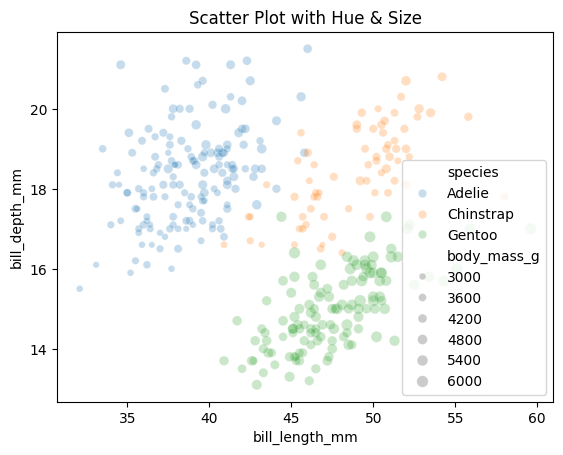

In [25]:
# Scatterplot
import seaborn as sns
import matplotlib.pyplot as plt

# Sample data
df_penguins = sns.load_dataset("penguins")

# Add third variable (species as hue, body_mass as size)
sns.scatterplot(data=df_penguins,
                x="bill_length_mm", y="bill_depth_mm",
                hue="species", 
                size="body_mass_g",
                alpha=0.25)  # very helpful when points overlap, goes from 0 to 1 (transparent to opaque)
plt.title("Scatter Plot with Hue & Size")
plt.show()


## Box Plots 

Show medians, quartiles, and outliers.

Required:
- `data = dataframe`: your dataset
- `x = 'fieldname of category'`: categorical variable
- `y = 'fieldname of quantitative'`: quantitative variable

Optional:

- `hue = 'fieldname of category'`: adds color grouping for each box


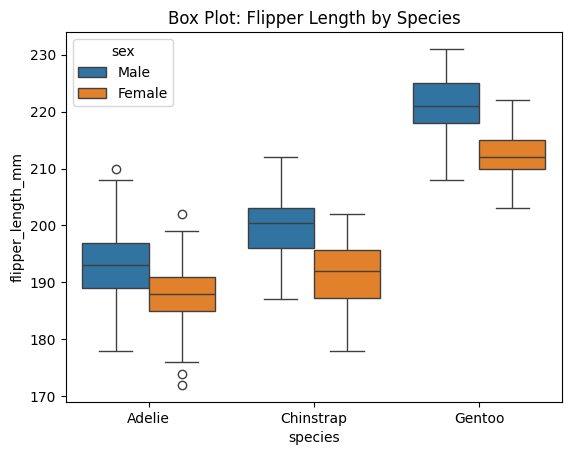

In [26]:
# Boxplot
import seaborn as sns
import matplotlib.pyplot as plt

df_penguins = sns.load_dataset("penguins")

# Box plot: flipper length across species
sns.boxplot(data=df_penguins, x="species", y="flipper_length_mm", hue="sex")
plt.title("Box Plot: Flipper Length by Species")
plt.show()


## Violin Plots

Similar to boxplot, but shows more detail about distribution shape.

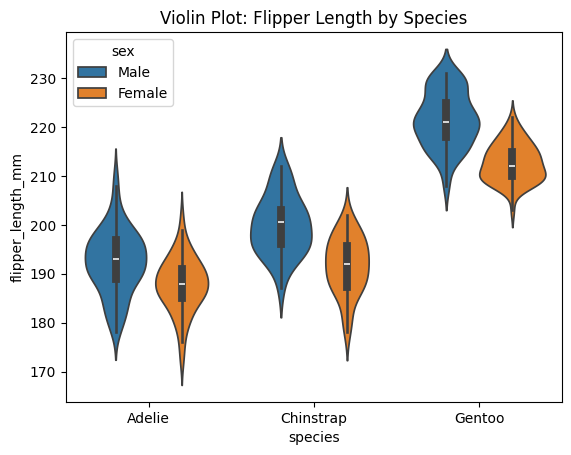

In [27]:
# Violin plot
import seaborn as sns
import matplotlib.pyplot as plt

df_penguins = sns.load_dataset("penguins")

# Box plot: flipper length across species
sns.violinplot(data=df_penguins, x="species", y="flipper_length_mm", hue="sex")
plt.title("Violin Plot: Flipper Length by Species")
plt.show()


# Pair Plots
Show relationships between all pairs of quantitative variables.

Required:
- `data = dataframe`: your dataset

Optional:
- `hue = 'fieldname of category'`: adds color grouping for each point
- `kind = 'scatter'`: type of plot to show in the off-diagonal (default is scatter, but can also be 'reg' for regression line, 'kde' for kernel density estimate, etc.)
- `alpha`: transparency level for points in scatter plots (default is 1, fully opaque). You can only use this with the following line (and you must use the reg kind argument):
```python
sns.pairplot(data=df, hue='category', kind='reg', plot_kws={'alpha': 0.25})
```


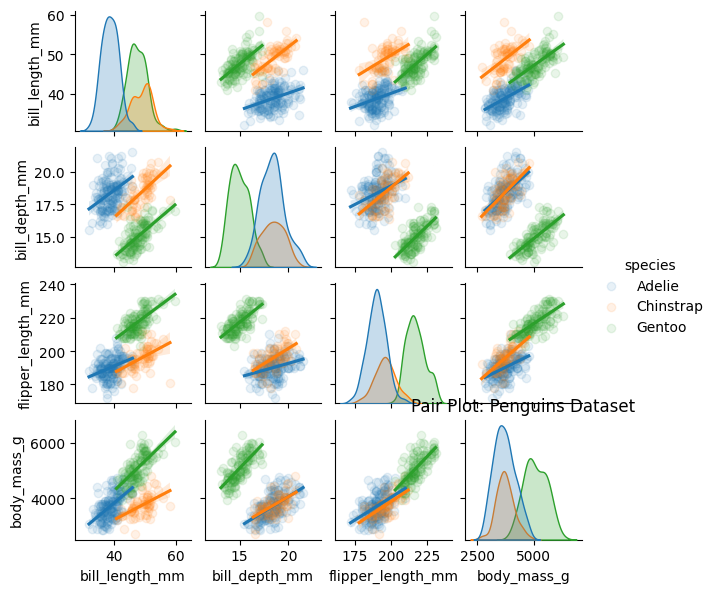

In [28]:
# Pairplot
import seaborn as sns
import matplotlib.pyplot as plt

df_penguins = sns.load_dataset("penguins")

# Box plot: flipper length across species
sns.pairplot(data=df_penguins, 
        hue="species",
        kind="reg",
        height=1.5, 
        plot_kws={'scatter_kws': {'alpha': 0.1}})
plt.title("Pair Plot: Penguins Dataset")
plt.show()



# Sample Code

The below code is useful for a quick overview of all variables in a dataset. It creates a plot for each variable. Numbers are shown with a histogram and boxplot, and text with a count plot.

Update it by updating `df` to your dataframe of choice.

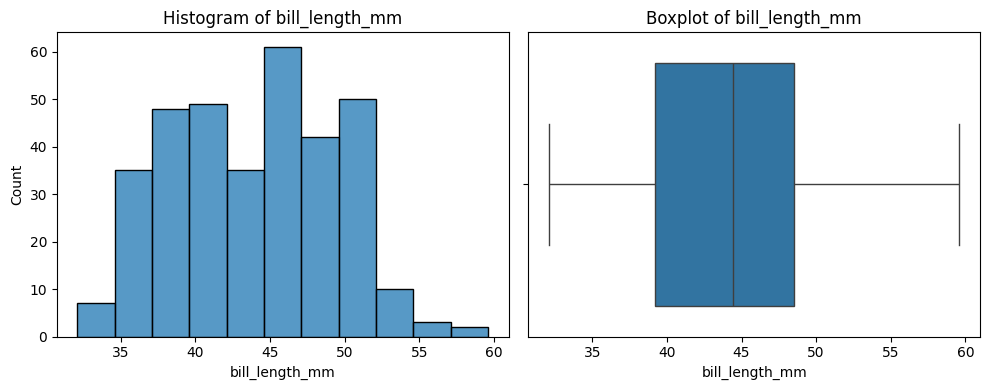

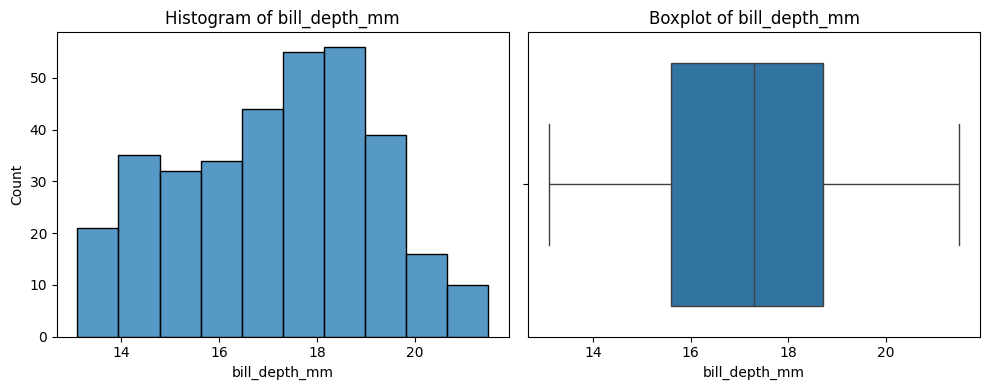

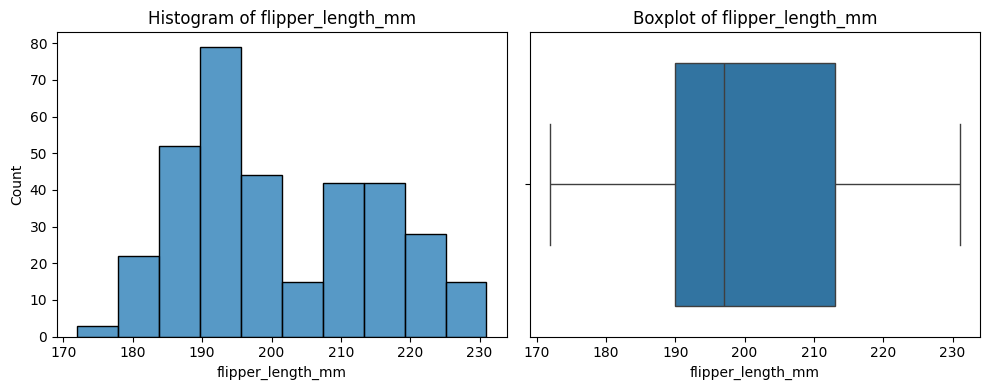

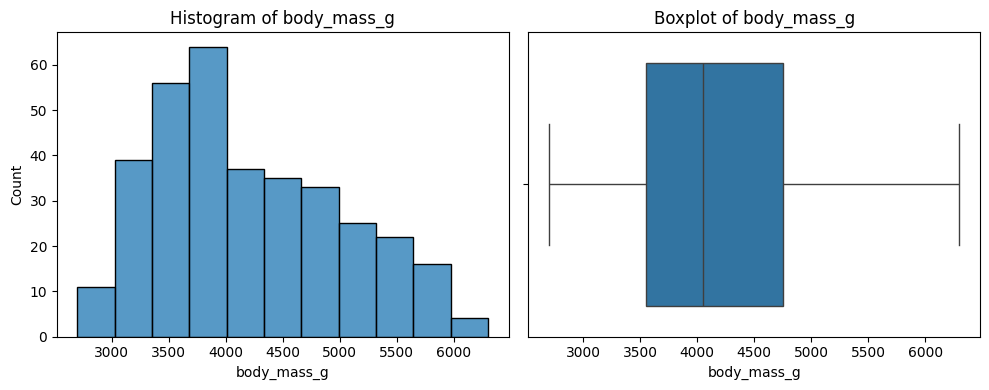

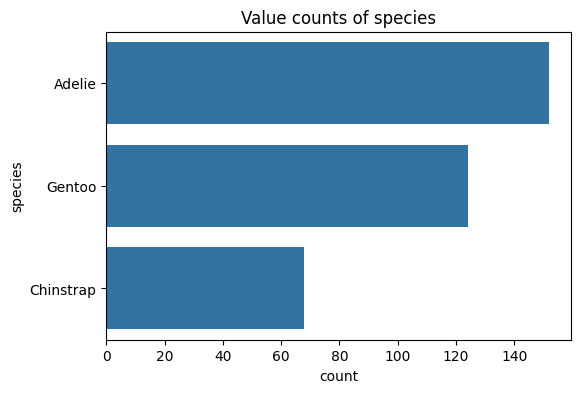

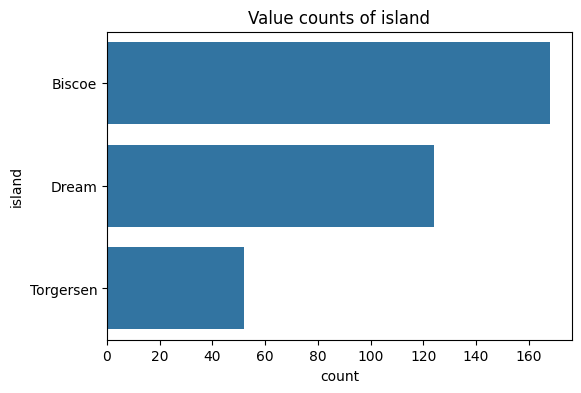

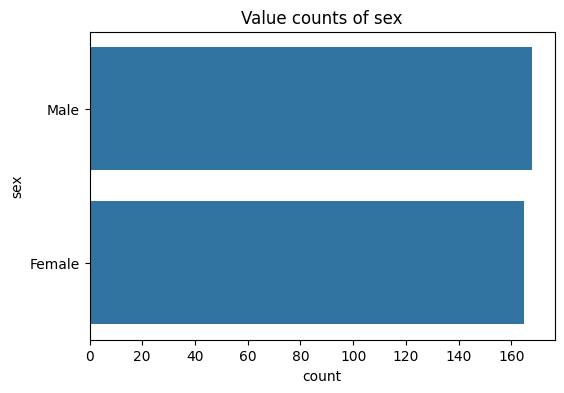

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("penguins")

number_columns = df.select_dtypes(include=['number']).columns.tolist()
text_columns = df.select_dtypes(include=['string', 'category']).columns.tolist()

# Print a histogram and boxplot for each numeric column
for col in number_columns:
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(df[col])
    plt.title(f'Histogram of {col}')
    
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col].dropna())
    plt.title(f'Boxplot of {col}')
    
    plt.tight_layout()
    plt.show()

# Print a chart showing the distribution of values for each text column
for col in text_columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f'Value counts of {col}')
    plt.show()